# Deep, Himal, Yash
# Critical Thinking — Hypothesis Testing

**Activity:** "Do students who study more hours actually score higher in exams?"


In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pathlib import Path

# display settings
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Cell 2: Load the dataset 
csv_path = Path("score.csv")
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print("Loaded dataset from score.csv")
else:
   print("File study_scores.csv not found. Please check the path.")

df.head()

Loaded dataset from score.csv


,Hours,Scores
0,2.50,21
1,5.10,47
2,3.20,27
3,8.50,75
4,3.50,30


## 2 — Exploratory Data Analysis (EDA)

- Look at summary statistics
- Visualize distributions and scatter plot

In [3]:
# Cell 3: Summary statistics
df.describe()

,Hours,Scores
count,25.00,25.00
mean,5.01,51.48
std,2.53,25.29
min,1.10,17.00
25%,2.70,30.00
50%,4.80,47.00
75%,7.40,75.00
max,9.20,95.00


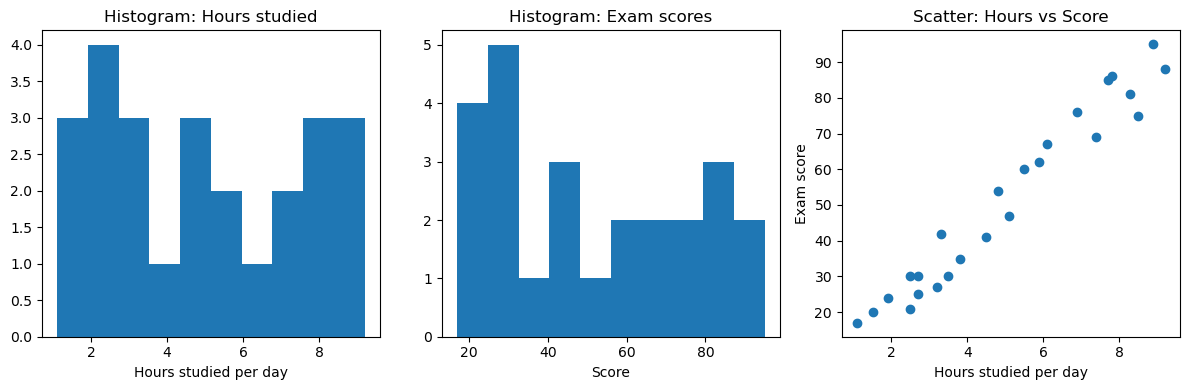

In [6]:
# Cell 4: Histograms & scatter plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(df['Hours'])
plt.title('Histogram: Hours studied')
plt.xlabel('Hours studied per day')

plt.subplot(1,3,2)
plt.hist(df['Scores'])
plt.title('Histogram: Exam scores')
plt.xlabel('Score')

plt.subplot(1,3,3)
plt.scatter(df['Hours'], df['Scores'])
plt.title('Scatter: Hours vs Score')
plt.xlabel('Hours studied per day')
plt.ylabel('Exam score')

plt.tight_layout()
plt.show()

## 3 — Formulate hypotheses

We will test the claim: **students who study more hours score higher**.

Two common formulations:

1) Correlation test (continuous × continuous):
- Null hypothesis H0: no positive correlation between hours studied and exam score (ρ = 0)
- Alternative H1: positive correlation (ρ > 0)

2) Group comparison (split into low/high study groups):
- H0: mean score in high-hours group ≤ mean score in low-hours group
- H1: mean score in high-hours group > mean score in low-hours group

We will run both approaches and show parametric and non-parametric options.

## 4 — Check assumptions for parametric tests

We'll run Shapiro-Wilk and Levene's test.

Shapiro test for Scores:
ShapiroResult(statistic=0.9168438083475086, pvalue=0.04343825780981888)

Shapiro test for Hours:
ShapiroResult(statistic=0.9401376688568953, pvalue=0.14911849228663898)


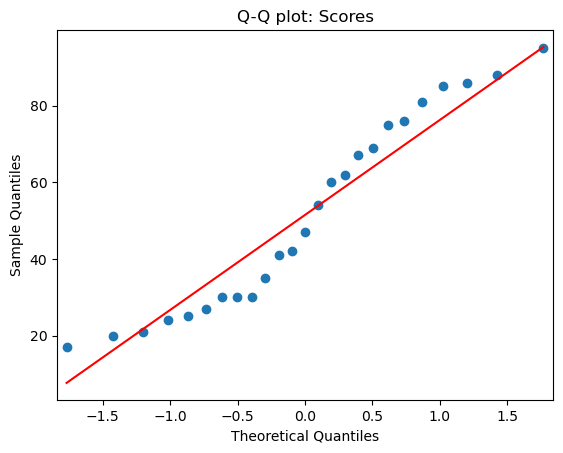

In [7]:
# Cell 5: Normality tests (Shapiro) and visual check
print('Shapiro test for Scores:')
print(stats.shapiro(df['Scores']))

print('\nShapiro test for Hours:')
print(stats.shapiro(df['Hours']))

# Q-Q plot for Scores
sm.qqplot(df['Scores'], line='s')
plt.title('Q-Q plot: Scores')
plt.show()

Hours is normally distributed and score is not (p value range 0.05)

n <= 2000 hona chahiye

## 5 — Correlation test (Pearson and Spearman)

If data are approximately normal and linear, Pearson correlation tests association (H1: positive correlation). If not, Spearman rank correlation is safer.

In [8]:
# Cell 6: Pearson correlation (two-sided and one-sided p-value)
pearson_r, pearson_p_two_sided = stats.pearsonr(df['Hours'], df['Scores'])
print(f'Pearson r = {pearson_r:.3f}, two-sided p = {pearson_p_two_sided:.4f}')

# For one-sided p-value (H1: r > 0), divide two-sided by 2 if r>0
if pearson_r > 0:
    pearson_p_one_sided = pearson_p_two_sided / 2
else:
    pearson_p_one_sided = 1 - (pearson_p_two_sided / 2)
print('One-sided p (H1: r > 0) =', round(pearson_p_one_sided, 4))

# Spearman rank correlation (non-parametric)
spearman_r, spearman_p = stats.spearmanr(df['Hours'], df['Scores'])
print(f'\nSpearman rho = {spearman_r:.3f}, p = {spearman_p:.4f}')

Pearson r = 0.976, two-sided p = 0.0000
One-sided p (H1: r > 0) = 0.0

Spearman rho = 0.972, p = 0.0000


p=0.0000 (i.e., < 0.001) so the correlation is statistically significant.

This relationship is very unlikely to be due to chance.

## 6 — Linear regression (as an alternative way to test association)

We can fit a simple linear model `Scores ~ Hours` and examine the coefficient and p-value.

In [9]:
# Cell 7: Linear regression using statsmodels
model = ols('Scores ~ Hours', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Scores   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.951
Method:                 Least Squares   F-statistic:                     465.8
Date:                Mon, 10 Nov 2025   Prob (F-statistic):           9.13e-17
Time:                        06:17:58   Log-Likelihood:                -77.514
No. Observations:                  25   AIC:                             159.0
Df Residuals:                      23   BIC:                             161.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4837      2.532      0.981      0.3

p is less so it is statistically significant

also r2 score shows it is a good fit

@ intercept = 0 results are insignificant

omnibus = residual normality, not so normal

JB = opp of omnibus (p > 0.005)

skew left

kurtosis(tailedness) < 3 so bit flatter curve

durbin-watson  = autocorrelation in residual (not much but mild)

autocorrelation = present depends on past or not(here not much)

## 7 — Group comparison: split by median hours

Create two groups (low and high study) using the median hours or a meaningful threshold, then compare means using t-test (parametric) and Mann-Whitney U (non-parametric).

In [10]:
# Cell 8: Create groups and compare
median_hours = df['Hours'].median()
df['study_group'] = np.where(df['Hours'] >= median_hours, 'high', 'low')
print('Median hours:', median_hours)
df.groupby('study_group').Scores.describe()

Median hours: 4.8


,count,mean,std,min,25%,50%,75%,max
study_group,,,,,,,,
high,13.00,72.69,14.37,47.00,62.00,75.00,85.00,95.00
low,12.00,28.50,7.88,17.00,23.25,28.50,31.25,42.00


In [11]:
# Cell 9: Levene's test for equal variances
high_scores = df.loc[df['study_group']=='high','Scores']
low_scores = df.loc[df['study_group']=='low','Scores']
levene_stat, levene_p = stats.levene(high_scores, low_scores)
print('Levene stat =', levene_stat, ', p =', levene_p)

# Independent t-test (two-sided) and one-sided p-value (H1: high > low)
t_stat, t_p_two = stats.ttest_ind(high_scores, low_scores, equal_var=(levene_p>0.05))
print('\nT-test stat =', t_stat, ', two-sided p =', t_p_two)
if t_stat > 0:
    t_p_one = t_p_two / 2
else:
    t_p_one = 1 - (t_p_two / 2)
print('One-sided p (H1: mean_high > mean_low) =', t_p_one)

# Mann-Whitney U (non-parametric)
u_stat, u_p = stats.mannwhitneyu(high_scores, low_scores, alternative='greater')  # test high > low
print('\nMann-Whitney U stat =', u_stat, ', p =', u_p)

Levene stat = 4.40214620575962 , p = 0.047077738089708894

T-test stat = 9.631870668306886 , two-sided p = 1.0053918690413611e-08
One-sided p (H1: mean_high > mean_low) = 5.0269593452068056e-09

Mann-Whitney U stat = 156.0 , p = 1.228625612795588e-05


## 8 — Effect size

Compute Cohen's d for the difference of means and report correlation coefficient as effect size for association.

In [12]:
# Cell 10: Effect sizes
# Cohen's d
mean_high = high_scores.mean()
mean_low = low_scores.mean()
sd_pooled = np.sqrt(((len(high_scores)-1)*high_scores.var() + (len(low_scores)-1)*low_scores.var()) / (len(high_scores)+len(low_scores)-2))
cohens_d = (mean_high - mean_low) / sd_pooled
print('Mean high =', mean_high, 'Mean low =', mean_low)
print("Cohen's d = %.3f" % cohens_d)

# r effect size from t statistic (optional)
n1 = len(high_scores)
n2 = len(low_scores)
t_stat_for_r = t_stat
r_effect = np.sqrt(t_stat_for_r**2 / (t_stat_for_r**2 + (n1+n2-2)))
print('r effect size =', round(r_effect,3))

Mean high = 72.6923076923077 Mean low = 28.5
Cohen's d = 3.770
r effect size = 0.895


## 9 — Conclusion template

Summarize results, mention p-values, effect sizes, and practical significance. State whether you reject H0 and whether the evidence supports the claim.

Example wording:
- "Pearson correlation between hours studied and exam score was r=..., one-sided p=.... This indicates ..."
- "Group comparison showed mean score in high-hours group was ... vs ... in low-hours group; Cohen's d=... suggesting ..."

In [13]:
# Cell 11: Quick automated conclusion (interpretation helper)
print('Pearson r = %.3f, one-sided p = %.4f' % (pearson_r, pearson_p_one_sided))
print('T-test one-sided p = %.4f, Cohen d = %.3f' % (t_p_one, cohens_d))

if pearson_p_one_sided < 0.05:
    print('\nInterpretation: There is statistically significant evidence of a positive association between hours studied and exam score (reject H0 at alpha=0.05).')
else:
    print('\nInterpretation: No statistically significant evidence of a positive association (fail to reject H0 at alpha=0.05).')

if t_p_one < 0.05:
    print('Group comparison: Mean(score_high) > Mean(score_low) is supported (one-sided test).')
else:
    print('Group comparison: No strong evidence that mean(score_high) > mean(score_low).')

Pearson r = 0.976, one-sided p = 0.0000
T-test one-sided p = 0.0000, Cohen d = 3.770

Interpretation: There is statistically significant evidence of a positive association between hours studied and exam score (reject H0 at alpha=0.05).
Group comparison: Mean(score_high) > Mean(score_low) is supported (one-sided test).
